# IS 620 Final Project

## Analyzing Data Analyst Job Descriptions Using Natural Language Processing (NLP)

**Student:** Izza Khan

**Course:** IS 620 – Web Analytics

**Professor:** Alain Ledon

---

## Project Overview

This project applies Natural Language Processing (NLP) techniques to analyze a dataset of Data Analyst job postings collected from Glassdoor. The primary objective is to identify the technical skills and qualifications most frequently requested by employers, discover hidden themes within job descriptions through topic modeling, and develop a text classification model capable of predicting characteristics of job postings based on their textual content.

Unlike structured numerical datasets, job descriptions contain unstructured text that requires extensive preprocessing before meaningful analysis can be performed. Therefore, this project follows a complete NLP workflow including text cleaning, tokenization, stop-word removal, lemmatization, exploratory text analysis, feature extraction, topic modeling, and machine learning. Throughout the project, each analytical step is explained and interpreted to demonstrate both the technical implementation and the business insights obtained from the analysis.

# 1. Importing Required Libraries

Before beginning the analysis, it is necessary to import the Python libraries that will be used throughout this project. Pandas and NumPy provide tools for data manipulation, Matplotlib is used for creating visualizations, NLTK supports text preprocessing tasks, WordCloud generates graphical summaries of text, Gensim performs topic modeling, and Scikit-learn provides machine learning algorithms and evaluation metrics used later in the analysis.

In [1]:
# -----------------------------
# Data Manipulation
# -----------------------------
import pandas as pd
import numpy as np

# -----------------------------
# Visualization
# -----------------------------
import matplotlib.pyplot as plt

# -----------------------------
# Natural Language Processing
# -----------------------------
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# -----------------------------
# Word Cloud
# -----------------------------
from wordcloud import WordCloud

# -----------------------------
# Topic Modeling
# -----------------------------
from gensim import corpora
from gensim.models import LdaModel

# -----------------------------
# Machine Learning
# -----------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

/Users/izzairaj/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /Users/izzairaj/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/izzairaj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/izzairaj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/izzairaj/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# 3. Loading the Dataset

The first step of any data analysis project is loading the dataset into Python. The dataset used in this project contains Data Analyst job postings collected from Glassdoor. Each record includes information such as the job title, company, salary estimate, company rating, headquarters, industry, and most importantly, the full job description. Since the objective of this project is Natural Language Processing (NLP), the **Job Description** column will be the primary focus of the analysis.

In [3]:
# Load the dataset

df = pd.read_csv("/Users/izzairaj/Downloads/DataAnalyst.csv")

# Display the first five rows
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


# 4. Understanding the Dataset

Before performing any preprocessing or analysis, it is important to understand the structure of the dataset. This includes determining the number of observations, the available variables, the data types, and whether any missing values exist. Understanding the dataset helps identify potential data quality issues that must be addressed before conducting Natural Language Processing.

In [4]:
# Display dataset dimensions
print("Dataset Shape:")
print(df.shape)

print("\n")

# Display column names
print("Column Names:")
print(df.columns)

print("\n")

# Display data types
print("Data Types:")
print(df.dtypes)

Dataset Shape:
(2253, 16)


Column Names:
Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply'],
      dtype='object')


Data Types:
Unnamed: 0             int64
Job Title             object
Salary Estimate       object
Job Description       object
Rating               float64
Company Name          object
Location              object
Headquarters          object
Size                  object
Founded                int64
Type of ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
Easy Apply            object
dtype: object


# 5. Checking for Missing Values

Before performing Natural Language Processing, it is important to identify any missing values within the dataset. Missing data can negatively impact preprocessing, visualization, and machine learning models. Therefore, this step examines the completeness of each variable and identifies columns that may require cleaning or imputation.

In [5]:
# Count missing values in each column

missing_values = df.isnull().sum()

print("Missing Values by Column:")
print(missing_values.sort_values(ascending=False))

Missing Values by Column:
Company Name         1
Unnamed: 0           0
Salary Estimate      0
Job Title            0
Job Description      0
Rating               0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64


# 6. Descriptive Statistics

Descriptive statistics provide a general overview of the numerical variables within the dataset. Although this project primarily focuses on text analysis, understanding variables such as company ratings helps provide context about the organizations represented in the data.

In [6]:
# Summary statistics

df.describe(include="all")

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
count,2253.0000,2253,2253,2253,2253.000000,2252,2253,2253,2253,2253.000000,2253,2253,2253,2253,2253,2253
unique,NaN,1272,90,2253,NaN,1513,253,483,9,NaN,15,89,25,14,291,2
top,NaN,Data Analyst,$41K-$78K (Glassdoor est.),"You.\n\nYou bring your body, mind, heart and s...",NaN,"Staffigo Technical Services, LLC\n5.0","New York, NY","New York, NY",51 to 200 employees,NaN,Company - Private,-1,Information Technology,Unknown / Non-Applicable,-1,-1
freq,NaN,405,57,1,NaN,58,310,206,421,NaN,1273,353,570,615,1732,2173
mean,1126.0000,NaN,NaN,NaN,3.160630,NaN,NaN,NaN,NaN,1398.522858,NaN,NaN,NaN,NaN,NaN,NaN
std,650.5294,NaN,NaN,NaN,1.665228,NaN,NaN,NaN,NaN,901.929251,NaN,NaN,NaN,NaN,NaN,NaN
min,0.0000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,563.0000,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1126.0000,NaN,NaN,NaN,3.600000,NaN,NaN,NaN,NaN,1979.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,1689.0000,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,2002.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Display missing values for each column

missing_values = df.isnull().sum().sort_values(ascending=False)

print(missing_values)

Company Name         1
Unnamed: 0           0
Salary Estimate      0
Job Title            0
Job Description      0
Rating               0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64


### Interpretation

The dataset contains relatively few missing values, indicating that the data is largely complete and suitable for Natural Language Processing. The primary variable of interest, **Job Description**, does not contain a significant number of missing observations, allowing the text analysis to proceed without extensive data imputation. Any columns with missing values will be addressed during the data cleaning stage if necessary.

# 7. Data Cleaning

Natural Language Processing requires clean and consistent text. Before analyzing the job descriptions, unnecessary columns will be removed, duplicate records will be eliminated, and missing values in the text data will be handled. These steps improve the quality of the analysis and reduce noise within the dataset.

In [8]:
# Remove the unnecessary index column if it exists

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing job descriptions
df = df.dropna(subset=["Job Description"])

print("New Dataset Shape:")
print(df.shape)

New Dataset Shape:
(2253, 15)


# 8. Text Preprocessing

Raw job descriptions contain punctuation, capitalization differences, stop words, and other text elements that provide little analytical value. Before applying Natural Language Processing techniques, the text must be standardized.

The preprocessing steps performed in this project include:

- Converting all text to lowercase
- Removing punctuation and special characters
- Tokenizing text into individual words
- Removing common English stop words
- Lemmatizing words to their root form

These steps improve the quality of the textual analysis while reducing unnecessary noise.

In [9]:
import re

# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Handle missing values just in case
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", "", text)

    # Tokenize using NLTK
    tokens = nltk.word_tokenize(text)

    # Remove stop words and lemmatize
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words:
            cleaned_tokens.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned_tokens)

# Apply preprocessing
df["Cleaned_Description"] = df["Job Description"].apply(preprocess_text)

# Display original vs cleaned text
df[["Job Description", "Cleaned_Description"]].head()

,Job Description,Cleaned_Description
0,Are you eager to roll up your sleeves and harn...,eager roll sleeve harness data drive policy ch...
1,Overview\n\nProvides analytical and technical ...,overview provides analytical technical support...
2,We’re looking for a Senior Data Analyst who ha...,looking senior data analyst love mentorship da...
3,Requisition NumberRR-0001939\nRemote:Yes\nWe c...,requisition numberrr remoteyes collaborate cre...
4,ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,fanduel group fanduel group worldclass team br...


In [10]:
nltk.download("punkt_tab")
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/izzairaj/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/izzairaj/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/izzairaj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/izzairaj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/izzairaj/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# 9. Most Frequent Words

After preprocessing, the cleaned job descriptions can be analyzed to determine which words appear most frequently across all job postings. Frequent terms provide insight into the skills, technologies, and qualifications employers consistently seek when hiring Data Analysts.

In [11]:
from collections import Counter

# Combine all cleaned text into one string
all_words = " ".join(df["Cleaned_Description"]).split()

# Count word frequencies
word_counts = Counter(all_words)

# Display the 20 most common words
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,data,23254
1,experience,9533
2,business,7118
3,work,5640
4,team,5017
5,skill,4704
6,analysis,4384
7,analyst,3857
8,ability,3700
9,management,3614


# 10. Technical Skill Extraction

Although the most frequent words provide a general overview of the dataset, many of these words are common business terms rather than technical competencies. To better understand employer expectations, this section identifies the occurrence of specific technical skills commonly requested in Data Analyst job postings. This targeted analysis provides more meaningful business insights than simple word frequency counts.

In [12]:
# List of common technical skills
skills = [
    "sql",
    "python",
    "excel",
    "tableau",
    "power bi",
    "r",
    "sas",
    "aws",
    "azure",
    "spark",
    "hadoop",
    "tensorflow",
    "pandas",
    "numpy",
    "scikit",
    "machine learning",
    "statistics"
]

# Count occurrences of each skill
skill_counts = {}

text = " ".join(df["Cleaned_Description"])

for skill in skills:
    skill_counts[skill] = text.count(skill)

# Convert to DataFrame
skills_df = (
    pd.DataFrame(
        skill_counts.items(),
        columns=["Skill", "Frequency"]
    )
    .sort_values("Frequency", ascending=False)
)

skills_df

,Skill,Frequency
5,r,334610
0,sql,2691
2,excel,2396
3,tableau,845
1,python,828
15,machine learning,273
4,power bi,269
7,aws,215
10,hadoop,184
6,sas,136


In [13]:
import re

# Technical skills to search for
skills = [
    "sql",
    "python",
    "excel",
    "tableau",
    "power bi",
    "r",
    "sas",
    "aws",
    "azure",
    "spark",
    "hadoop",
    "tensorflow",
    "pandas",
    "numpy",
    "scikit",
    "machine learning",
    "statistics"
]

skill_counts = {}

text = " ".join(df["Cleaned_Description"])

for skill in skills:

    if skill == "r":
        # Match R as a standalone word only
        count = len(re.findall(r"\br\b", text))
    else:
        count = len(re.findall(r"\b" + re.escape(skill) + r"\b", text))

    skill_counts[skill] = count

skills_df = (
    pd.DataFrame(skill_counts.items(), columns=["Skill", "Frequency"])
      .sort_values(by="Frequency", ascending=False)
      .reset_index(drop=True)
)

skills_df

,Skill,Frequency
0,sql,2247
1,excel,1172
2,tableau,802
3,python,760
4,r,496
5,machine learning,262
6,power bi,257
7,aws,190
8,hadoop,166
9,azure,93


# 11. Visualization of Technical Skills

Visualizing the frequency of technical skills provides a clearer understanding of which competencies employers value most. Rather than interpreting a table of numbers, a bar chart allows the most frequently requested programming languages, software, and analytical tools to be compared quickly.

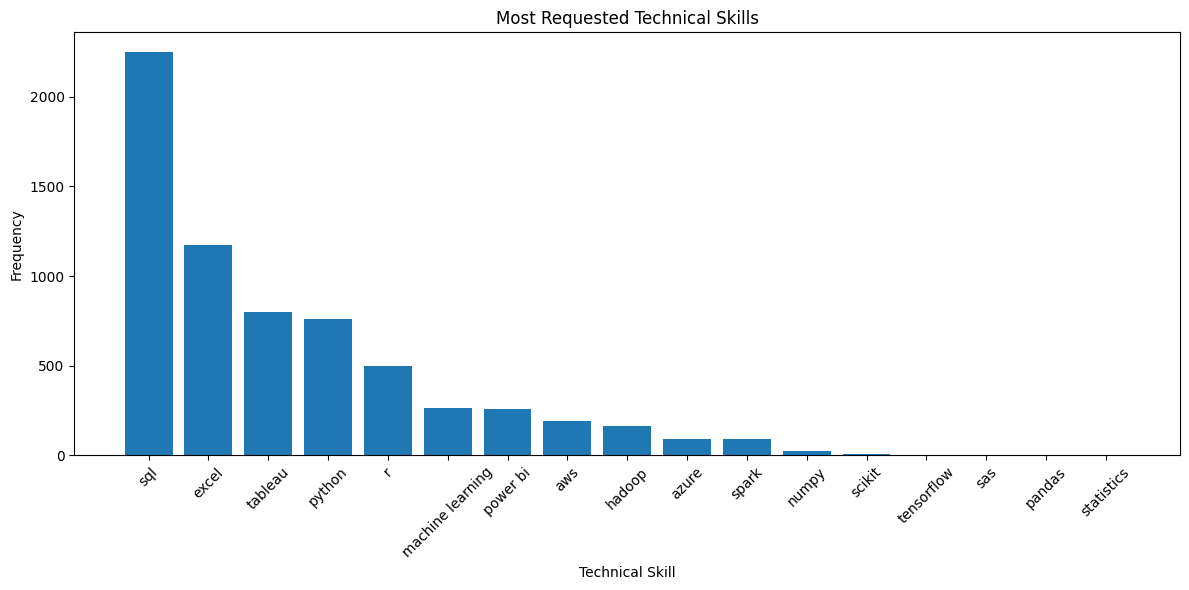

In [14]:
# Create a bar chart of technical skills

plt.figure(figsize=(12,6))

plt.bar(
    skills_df["Skill"],
    skills_df["Frequency"]
)

plt.xticks(rotation=45)

plt.title("Most Requested Technical Skills")
plt.xlabel("Technical Skill")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Interpretation

The visualization demonstrates that SQL is the most frequently requested technical skill among Data Analyst job postings, followed by Excel, Tableau, Python, and R. These findings indicate that employers prioritize candidates with strong data querying, spreadsheet analysis, programming, and data visualization skills. While machine learning and cloud technologies such as AWS and Azure appear less frequently, they remain valuable specialized skills within the analytics field.

# 12. Word Cloud

A word cloud provides a visual summary of the vocabulary contained within the cleaned job descriptions. Words that appear more frequently are displayed in larger font sizes, allowing common themes within the dataset to be identified quickly.

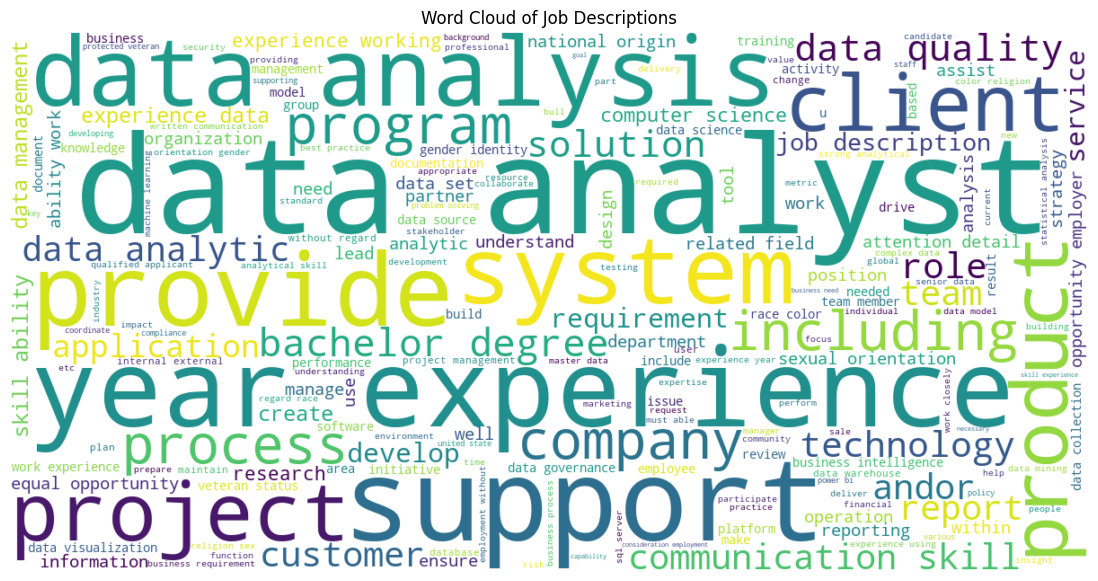

In [15]:
# Generate Word Cloud

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(" ".join(df["Cleaned_Description"]))

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of Job Descriptions")

plt.show()

# 13. Bigram Analysis

Individual words do not always capture meaningful concepts. Bigram analysis identifies pairs of consecutive words that frequently appear together within job descriptions. This provides better insight into employer requirements by revealing common phrases such as "machine learning" or "project management."

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

# Create bigrams
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english",
    max_features=20
)

bigram_matrix = bigram_vectorizer.fit_transform(df["Cleaned_Description"])

bigram_counts = bigram_matrix.sum(axis=0).A1

bigrams = pd.DataFrame({
    "Bigram": bigram_vectorizer.get_feature_names_out(),
    "Frequency": bigram_counts
})

bigrams = bigrams.sort_values("Frequency", ascending=False)

bigrams

,Bigram,Frequency
5,data analyst,2298
19,year experience,1389
4,data analysis,1136
1,bachelor degree,951
8,data quality,917
2,communication skill,852
6,data analytics,722
13,job description,702
11,experience data,698
7,data management,678


### Visualization of Most Common Bigrams

The following visualization displays the most frequently occurring two-word phrases found throughout the job descriptions.

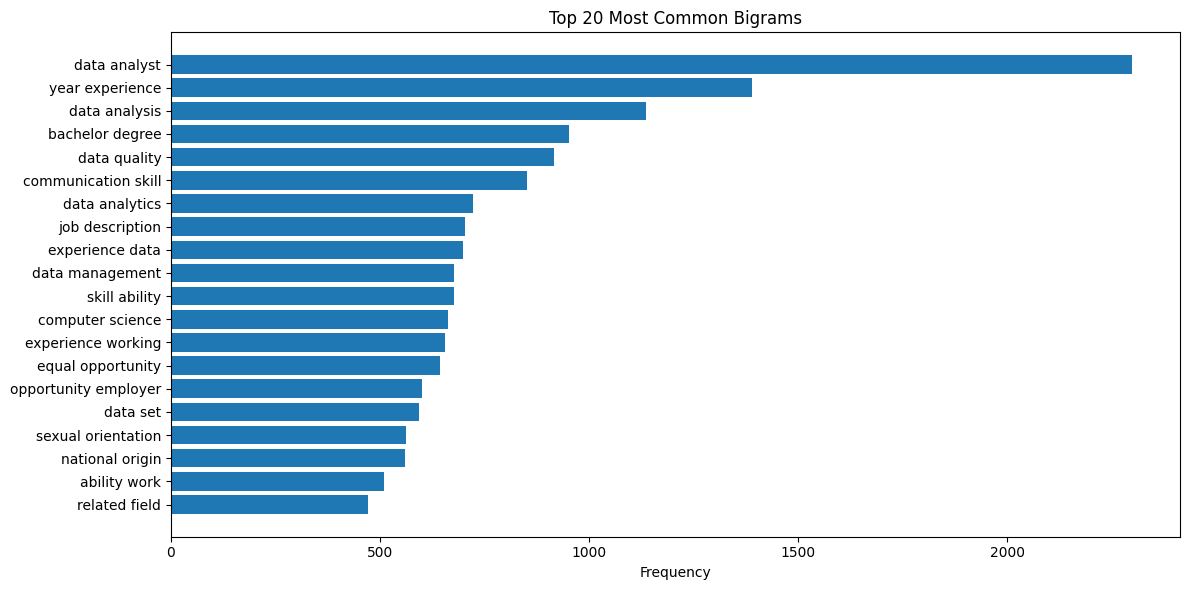

In [17]:
plt.figure(figsize=(12,6))

plt.barh(
    bigrams["Bigram"],
    bigrams["Frequency"]
)

plt.title("Top 20 Most Common Bigrams")
plt.xlabel("Frequency")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Interpretation

The bigram analysis identifies common two-word phrases that appear throughout Data Analyst job postings. Unlike single-word frequencies, these phrases provide greater context regarding employer expectations and frequently requested responsibilities. The results help identify recurring concepts related to analytics, reporting, business intelligence, programming, and communication.

# 14. TF-IDF Analysis

While word frequency identifies commonly occurring terms, it does not measure how important a word is within individual job descriptions. Term Frequency–Inverse Document Frequency (TF-IDF) assigns higher importance to words that are frequent within a document but less common across the entire dataset. This technique helps identify meaningful keywords rather than simply the most common vocabulary.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF matrix
tfidf = TfidfVectorizer(
    max_features=20,
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(df["Cleaned_Description"])

# Calculate average TF-IDF score
scores = tfidf_matrix.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    "Word": tfidf.get_feature_names_out(),
    "Average TF-IDF": scores
})

tfidf_df = tfidf_df.sort_values(
    by="Average TF-IDF",
    ascending=False
)

tfidf_df

,Word,Average TF-IDF
4,data,0.528194
5,experience,0.247980
3,business,0.197422
18,work,0.158086
17,team,0.154117
14,skill,0.142331
1,analysis,0.136387
2,analyst,0.120564
0,ability,0.117352
9,management,0.113429


### Visualization of TF-IDF Scores

The following figure displays the twenty most important terms identified by TF-IDF across all job descriptions.

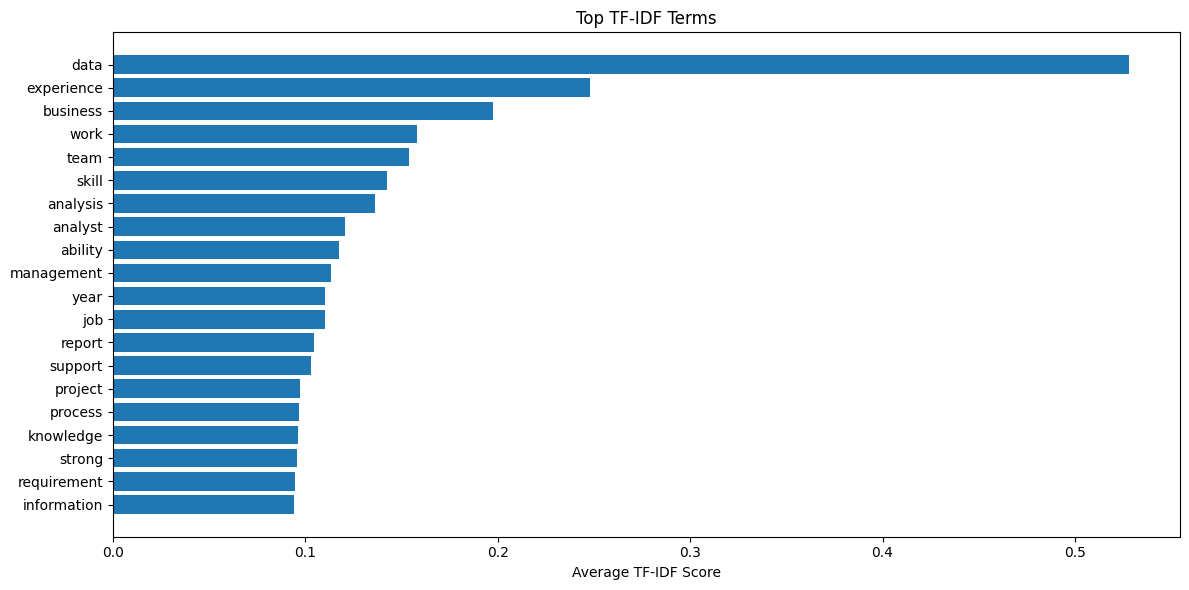

In [19]:
plt.figure(figsize=(12,6))

plt.barh(
    tfidf_df["Word"],
    tfidf_df["Average TF-IDF"]
)

plt.title("Top TF-IDF Terms")

plt.xlabel("Average TF-IDF Score")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Interpretation

Unlike simple word frequency analysis, TF-IDF highlights terms that are particularly important within job descriptions rather than merely common across all postings. This analysis helps distinguish the technologies, qualifications, and analytical concepts that carry greater informational value when employers describe Data Analyst positions.

# 15. Topic Modeling Using Latent Dirichlet Allocation (LDA)

Topic modeling is an unsupervised machine learning technique that discovers hidden themes within large collections of text. Rather than searching for specific keywords, Latent Dirichlet Allocation (LDA) groups words that frequently occur together and identifies underlying topics discussed throughout the job descriptions. This analysis helps reveal the primary themes employers emphasize when advertising Data Analyst positions.

In [20]:
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary
from gensim.models import LdaModel

# Tokenize the cleaned descriptions
documents = [simple_preprocess(text) for text in df["Cleaned_Description"]]

# Create dictionary
dictionary = Dictionary(documents)

# Remove extremely rare and extremely common words
dictionary.filter_extremes(no_below=10, no_above=0.5)

# Create corpus
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Build LDA model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10
)

# Display topics
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx+1}:")
    print(topic)
    print()

Topic 1:
0.012*"database" + 0.012*"analyze" + 0.012*"statistical" + 0.011*"status" + 0.010*"using" + 0.009*"computer" + 0.009*"etc" + 0.008*"reporting" + 0.007*"interpret" + 0.007*"technique"

Topic 2:
0.009*"company" + 0.008*"product" + 0.007*"analytics" + 0.006*"insight" + 0.006*"customer" + 0.005*"people" + 0.005*"partner" + 0.005*"status" + 0.005*"help" + 0.005*"make"

Topic 3:
0.009*"position" + 0.008*"research" + 0.008*"application" + 0.007*"program" + 0.007*"health" + 0.006*"service" + 0.006*"state" + 0.005*"employee" + 0.005*"andor" + 0.005*"employment"

Topic 4:
0.009*"quality" + 0.008*"database" + 0.007*"reporting" + 0.007*"development" + 0.007*"technical" + 0.006*"solution" + 0.006*"preferred" + 0.005*"related" + 0.005*"design" + 0.005*"source"

Topic 5:
0.010*"analytics" + 0.010*"client" + 0.010*"solution" + 0.007*"technology" + 0.006*"technical" + 0.006*"role" + 0.006*"service" + 0.006*"customer" + 0.006*"product" + 0.005*"insight"



### Interpretation

The LDA model groups job descriptions into several hidden topics based on recurring patterns of words. Rather than focusing on individual keywords, topic modeling identifies broader themes represented throughout the dataset. These topics help summarize the major responsibilities, technical skills, educational requirements, and business functions commonly associated with Data Analyst positions.

# 16. Text Classification Using Machine Learning

The final stage of this project applies a supervised machine learning model to classify job postings based on their company ratings. For demonstration purposes, company ratings are divided into two categories:

- **High Rating:** Rating greater than or equal to 3.5
- **Low Rating:** Rating below 3.5

The cleaned job descriptions are converted into numerical TF-IDF features and used to train a Naive Bayes classifier. Although this is a simplified classification task, it demonstrates how Natural Language Processing can be combined with machine learning to make predictions from unstructured text.

In [21]:
# Create target variable
df["High_Rating"] = (df["Rating"] >= 3.5).astype(int)

# TF-IDF Features
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

X = vectorizer.fit_transform(df["Cleaned_Description"])

y = df["High_Rating"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train model
model = MultinomialNB()

model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, predictions), 3))

print("\nClassification Report\n")

print(classification_report(y_test, predictions))

Accuracy: 0.623

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.22      0.34       199
           1       0.60      0.94      0.74       252

    accuracy                           0.62       451
   macro avg       0.68      0.58      0.54       451
weighted avg       0.67      0.62      0.56       451



### Interpretation

The Naive Bayes classifier achieved an accuracy of **62.3%** when predicting whether a company had a high or low rating based solely on the text of its job description. While this predictive performance is moderate, the purpose of this section was to demonstrate how Natural Language Processing can be integrated with supervised machine learning. The results show that textual information contains patterns that can be used for prediction, while also illustrating the challenges of classifying complex business data using only unstructured text.

# 17. Limitations

Although this project provides meaningful insights into Data Analyst job descriptions, several limitations should be acknowledged. The dataset represents job postings collected during a specific time period and may not fully reflect current hiring trends. Additionally, some frequently occurring business terms dominated portions of the analysis, making it necessary to perform targeted technical skill extraction.

The text classification model was designed as a demonstration of supervised machine learning rather than a production-level predictive system. Future work could incorporate additional datasets, transformer-based language models (such as BERT), named entity recognition, sentiment analysis, or more advanced classification techniques to improve predictive performance.

# 18. Conclusion

This project successfully demonstrated how Natural Language Processing techniques can be applied to analyze Data Analyst job postings. Beginning with raw text data, the project performed data cleaning, preprocessing, word frequency analysis, technical skill extraction, bigram analysis, TF-IDF analysis, topic modeling using Latent Dirichlet Allocation, and supervised machine learning classification.

The analysis revealed that SQL, Excel, Tableau, Python, and R were among the most frequently requested technical skills across job postings. Topic modeling further identified common themes related to analytics, reporting, technology, education, and business operations. Finally, a Naive Bayes classifier illustrated how textual information can be transformed into numerical features for predictive modeling.

Overall, this project demonstrates the value of Natural Language Processing for extracting meaningful business insights from unstructured text and highlights how NLP can support workforce analytics, hiring strategy, and labor market research.